# Graph Builder Quick Test
이 노트북은 main.py에서 사용되는 노드 구성을 기반으로 그래프를 빠르게 빌드하고 테스트하기 위한 예제입니다.

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from startup import Container
from src.graph.nodes import (
    # NaverNewsSearcherNode,
    GoogleSearcherNode,
    # RetrieveESGNode,
    # ReportAssistantNode,
    # ChosunRSSFeederNode,
    # WSJEconomyRSSFeederNode,
    # WSJMarketRSSFeederNode,
    CompanyFactsAnalyzerNode,
    # USFinancialAnalyzerNode,
    EdgarReportNode,
)
from src.graph.builder import SupervisorGraphBuilder

2025-07-30 07:56:39,156 - pyrate_limiter - INFO - Initializing default bucket(InMemoryBucket) with rates: [limit=10/1000]


In [3]:
container = Container()
graph_builder: SupervisorGraphBuilder = container.supervisor_graph()

# main.py와 동일하게 노드를 등록합니다.
# graph_builder.add_node(NaverNewsSearcherNode())
graph_builder.add_node(GoogleSearcherNode())
# graph_builder.add_node(RetrieveESGNode())
# graph_builder.add_node(ReportAssistantNode())
# graph_builder.add_node(ChosunRSSFeederNode())
# graph_builder.add_node(WSJEconomyRSSFeederNode())
# graph_builder.add_node(WSJMarketRSSFeederNode())
graph_builder.add_node(CompanyFactsAnalyzerNode())
# graph_builder.add_node(USFinancialAnalyzerNode())
graph_builder.add_node(EdgarReportNode())

graph_builder.build()

2025-07-30 07:57:25,147 - market_agent - INFO - Building graph...
2025-07-30 07:57:25,148 - market_agent - INFO - Graph built successfully
2025-07-30 07:57:25,148 - market_agent - INFO - Graph built successfully


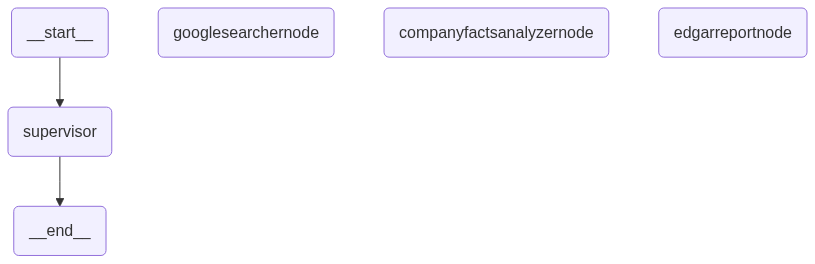

In [4]:
from IPython.display import display, Image

# mermaid 그래프 출력 (langgraph의 기능을 활용합니다)
display(Image(graph_builder._graph.get_graph().draw_mermaid_png()))

In [5]:
# 그래프 실행 테스트
state = {
    "messages": [("human", "애플 10-K 보고서 찾아줘")],
    "llm": container.llm()
}
result = graph_builder.execute(state)
print(result)

2025-07-30 07:57:40,072 - market_agent - INFO - Executing graph with state: {'messages': [('human', '애플 10-K 보고서 찾아줘')], 'llm': ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x7f2353141cf0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7f235315ca90>, root_client=<openai.OpenAI object at 0x7f2353a66560>, root_async_client=<openai.AsyncOpenAI object at 0x7f2353141db0>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.openai.com/v1'), 'members': ['googlesearchernode', 'companyfactsanalyzernode', 'edgarreportnode']}


===================================================================================================================

2025-07-30 07:57:40,079 - market_agent.nodes.supervisornode - INFO - Starting SupervisorNode...
2025-07-30 07:57:40,079 - market_agent.nodes.supervisornode - INFO - prompt: 
You are a supervisor managing a team of worker nodes: googlesearchernode, companyfactsanalyzernode, edgarreportnode. Your task is to coordinate these workers to fulfill the user's request, based on the full conversation history and any prior worker outputs. 

The team consists of the following specialized groups and their members:

<News Data Collection>
**Members**: googlesearcher, navernewssearcher, chosunrssfeeder, wsjmarketrssfeeder, weeklyreporter
Handles all tasks related to gathering, summarizing, and extracting structured news data relevant to the subject. These workers identify key news events, sentiment, and extract useful information for the report.
<News Data Collection/>

<Financial Statement Data Collection>
**Members**: hantoofinancialanalyzer, usfinancialanalyzer, stockinfo
Responsible for acquiring

===================================================================================================================

===================================================================================================================

...

===================================================================================================================

2025-07-30 07:58:25,403 - market_agent.nodes.supervisornode - INFO - Starting SupervisorNode...
2025-07-30 07:58:25,404 - market_agent.nodes.supervisornode - INFO - prompt: 
You are a supervisor managing a team of worker nodes: googlesearchernode, companyfactsanalyzernode, edgarreportnode. Your task is to coordinate these workers to fulfill the user's request, based on the full conversation history and any prior worker outputs. 

The team consists of the following specialized groups and their members:

<News Data Collection>
**Members**: googlesearcher, navernewssearcher, chosunrssfeeder, wsjmarketrssfeeder, weeklyreporter
Handles all tasks related to gathering, summarizing, and extracting structured news data relevant to the subject. These workers identify key news events, sentiment, and extract useful information for the report.
<News Data Collection/>

<Financial Statement Data Collection>
**Members**: hantoofinancialanalyzer, usfinancialanalyzer, stockinfo
Responsible for acquiring

===================================================================================================================

2025-07-30 07:58:26,212 - market_agent - INFO - Execution completed with result: {'messages': [HumanMessage(content='애플 10-K 보고서 찾아줘', additional_kwargs={}, response_metadata={}, id='b77a687a-0252-4e6b-b967-850ec0e29933'), HumanMessage(content='📊 **SEC 10-K 보고서 분석** - Apple Inc.\n\n### 🏢 회사 정보\n• **회사명**: Apple Inc.  \n• **CIK**: 0000320193  \n• **티커**: AAPL  \n• **SIC 코드**: 3571  \n• **업종**: Electronic Computers  \n• **설립 주**: CA  \n\n### 📋 최근 10-K 파일링 (29건)\n**1. 2024-11-01**  \n   • Accession Number: 0000320193-24-000123  \n\n**2. 2023-11-03**  \n   • Accession Number: 0000320193-23-000106  \n\n**3. 2022-10-28**  \n   • Accession Number: 0000320193-22-000108  \n\n**4. 2021-10-29**  \n   • Accession Number: 0000320193-21-000105  \n\n**5. 2020-10-30**  \n   • Accession Number: 0000320193-20-000096  \n\n### 🔗 추가 정보\n• **SEC EDGAR 페이지**: [https://www.sec.gov/edgar/browse/?CIK=0000320193](https://www.sec.gov/edgar/browse/?CIK=0000320193)  \n• **최신 파일링 날짜**: 2024-11-01  \n• **분석된 보고서 타입**

{'messages': [HumanMessage(content='애플 10-K 보고서 찾아줘', additional_kwargs={}, response_metadata={}, id='b77a687a-0252-4e6b-b967-850ec0e29933'), HumanMessage(content='📊 **SEC 10-K 보고서 분석** - Apple Inc.\n\n### 🏢 회사 정보\n• **회사명**: Apple Inc.  \n• **CIK**: 0000320193  \n• **티커**: AAPL  \n• **SIC 코드**: 3571  \n• **업종**: Electronic Computers  \n• **설립 주**: CA  \n\n### 📋 최근 10-K 파일링 (29건)\n**1. 2024-11-01**  \n   • Accession Number: 0000320193-24-000123  \n\n**2. 2023-11-03**  \n   • Accession Number: 0000320193-23-000106  \n\n**3. 2022-10-28**  \n   • Accession Number: 0000320193-22-000108  \n\n**4. 2021-10-29**  \n   • Accession Number: 0000320193-21-000105  \n\n**5. 2020-10-30**  \n   • Accession Number: 0000320193-20-000096  \n\n### 🔗 추가 정보\n• **SEC EDGAR 페이지**: [https://www.sec.gov/edgar/browse/?CIK=0000320193](https://www.sec.gov/edgar/browse/?CIK=0000320193)  \n• **최신 파일링 날짜**: 2024-11-01  \n• **분석된 보고서 타입**: 10-K  ', additional_kwargs={}, response_metadata={}, name='edgar_report', id='1